In [ ]:
# Importación de librerías y módulos necesarios

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, learning_curve
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

In [ ]:
# Carga y preparación de datos

df_train = pd.read_csv('df_voices_train.csv')

# Creación de variable objetivo

df_train['y'] = df_train['Key'].map({
    'bonafide': 0,
    'spoof': 1
})

# Separación de X e y

drop_columns = ['Key', 'file_name', 'User_ID', 'Spoofing_ID', 'y']

X = df_train.drop(columns=drop_columns, errors='ignore')
y = df_train['y']

print(f"Dataset cargado: {X.shape[0]} muestras y {X.shape[1]} variables\n")

# Groups para evitar leakage

groups = df_train['Spoofing_ID']

Dataset cargado: 25380 muestras y 22 variables



In [ ]:
# Especificación de modelo escogido

pipeline = Pipeline([
    ('scaler', StandardScaler()),

    ('model', RandomForestClassifier(
        n_estimators=250,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

In [ ]:
# Configuración de cross-validation

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
# Especificación de learning curve

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    groups=groups,
    cv=cv,

    scoring=make_scorer(f1_score),

    # Tamaños absolutos

    train_sizes=np.arange(500, 17780, 500),

    n_jobs=-1,

    shuffle=True,
    random_state=42
)

# Promedios

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

validation_mean = np.mean(validation_scores, axis=1)
validation_std = np.std(validation_scores, axis=1)

In [ ]:
results_df = pd.DataFrame({
    'Muestras entrenamiento': train_sizes,
    'F1 Train': train_mean,
    'F1 Validation': validation_mean
})

print("Resultados de learning curve:")

print(results_df)

Resultados de learning curve:
    Muestras entrenamiento  F1 Train  F1 Validation
0                      500       1.0       0.928960
1                     1000       1.0       0.922526
2                     1500       1.0       0.914210
3                     2000       1.0       0.912299
4                     2500       1.0       0.912419
5                     3000       1.0       0.912849
6                     3500       1.0       0.912743
7                     4000       1.0       0.908486
8                     4500       1.0       0.907868
9                     5000       1.0       0.907411
10                    5500       1.0       0.906555
11                    6000       1.0       0.907490
12                    6500       1.0       0.907934
13                    7000       1.0       0.906249
14                    7500       1.0       0.906962
15                    8000       1.0       0.906922
16                    8500       1.0       0.905143
17                    9000       1

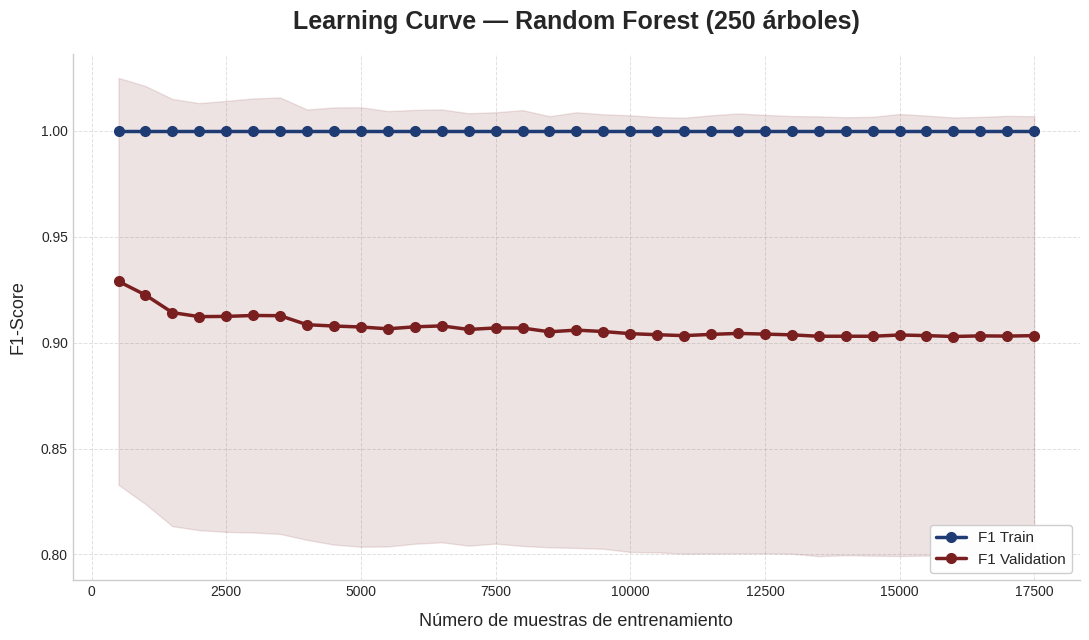

In [ ]:
# Estilo general profesional

plt.style.use('seaborn-v0_8-whitegrid')

# Colores más sobrios / business

train_color = '#1F3B73'       # Azul oscuro
val_color = '#7A1F1F'         # Rojo oscuro

# Figura

fig, ax = plt.subplots(figsize=(11, 6.5))

# Curva de entrenamiento

ax.plot(
    train_sizes,
    train_mean,
    marker='o',
    markersize=7,
    linewidth=2.5,
    color=train_color,
    label='F1 Train'
)

ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    color=train_color,
    alpha=0.12
)

# Curva de validación

ax.plot(
    train_sizes,
    validation_mean,
    marker='o',
    markersize=7,
    linewidth=2.5,
    color=val_color,
    label='F1 Validation'
)

ax.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    color=val_color,
    alpha=0.12
)

# Títulos y etiquetas

ax.set_title(
    'Learning Curve — Random Forest (250 árboles)',
    fontsize=18,
    fontweight='bold',
    pad=18
)

ax.set_xlabel(
    'Número de muestras de entrenamiento',
    fontsize=13,
    labelpad=10
)

ax.set_ylabel(
    'F1-Score',
    fontsize=13,
    labelpad=10
)

# Leyenda

legend = ax.legend(
    loc='lower right',
    frameon=True,
    fontsize=11
)

legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.95)

# Grid y bordes

ax.grid(
    which='major',
    linestyle='--',
    linewidth=0.7,
    alpha=0.6
)

# Quitar bordes superiores y derechos

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Mejor espaciado

plt.tight_layout()

plt.show()